# Reaction–diffusion in d=2 — a UV-finite loop above d=1

**Showcases:** the pipeline in **d=2** with a *convergent* loop. The quadratic nonlinearity gives a cubic MSR vertex, so the 1-loop self-energy is a genuine momentum-dependent **bubble** $\propto g^2$; the integral $\int d^2\ell$ behaves as $\int d^2\ell/\ell^4$ in the UV, which converges for $d<4$ (the φ⁴ upper critical dimension). So the d=2 correction is **finite — no cutoff**.

$$\partial_t\phi = D\,\nabla^2\phi - \mu\phi - g\phi^2 + \eta,\qquad x\in\mathbb{R}^2,\qquad \langle\eta\,\eta\rangle = 2T\,\delta\,\delta.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'api' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'api')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for simulations/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the model file — domain, fields, parameters, kernels, and the governing equation.

In [2]:
MODEL = 'reaction_diffusion_2d'
model, mod = dd.load_model(MODEL)
dd.describe_model(model, mod);

────────────────────────────────────────────────────────────────────────
  reaction-diffusion (d=2)
────────────────────────────────────────────────────────────────────────
Domain         : SPDE · d=2 · boundary=infinite · initial=stationary
Fields         : phi (x∈ℝ^2)
Response fields: phit
Mean-field saddle: phistar
Governing eqn  : (Dt + mu - D*Laplacian)*phi = -g*phi^2
Action  S      : phit*((Dt + mu - D*Laplacian)*phi + g*phi^2) - T*phit^2
Parameters (defaults):
    mu = 1.0  (positive)
    D = 1.0  (positive)
    g = 0.2  (real)
    T = 1.0  (positive)
Suggested run  : k=2, max_ell=1

2D reaction–diffusion field with a QUADRATIC nonlinearity — the d=2
companion of ``reaction_diffusion_quadratic_1d``.  Its 1-loop self-energy
is a genuine momentum-dependent **bubble** (not a constant mass shift),
and the loop ``∫ d²ℓ`` is closed-form in any dimension via the analytic
Symanzik momentum reduction.

    ∂_t φ = D ∇²φ − μ φ − g φ²  + η,
    ⟨η(x,t) η(x',t')⟩ = 2T δ²(x−x') δ(t−t').

MSR

## 2. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). In d=2 the separation χ is a vector, so the correlator is C(χ¹,χ²,τ); `dd.plot_cumulant` shows the three axis slices (χ¹, χ², τ — tree and tree+1loop) and the three pairwise heatmaps. The plot is the **model only** — the simulation is added in §3.

In [3]:
rs = np.linspace(0.0, 4.0, 17)      # radial separations r = |χ| ≥ 0 (includes 0 for the τ-slice at χ=0)
cfg = dd.Config(
    k=2, max_ell=1,                 # two-point ⟨φφ⟩, tree + the finite d=2 1-loop bubble
    external_fields=[('dphi', 1), ('dphi', 1)],
    parameters={'mu': 1.0, 'D': 1.0, 'g': 0.2, 'T': 1.0},
    chi_grid=rs,                # radial separations (explicit array, not a (lo,hi,n) tuple)
    tau_grid=(-3.0, 3.0, 13),   # τ RANGE → the full C(χ¹,χ²,τ): 3 axis slices + 3 pairwise heatmaps
#   ─── optional · uncomment any (swap the leading # for a space) · dd.config_options() lists all ───
#   output='moment',              # 'cumulant'(default) | 'moment' | 'central_moment'
#   spatial_points=...,           # k≥3 spatial: (n_pts, k−1, 2) of explicit (x_j, τ_j) events
#   dyson_order=2, reference_diffusion=1.0,   # coupled unequal-D Dyson dressing
#   fixed_point_index=0,          # multi-root saddle: which stable root (0, 1, …)
#   mf_dae_n_starts=64, mf_dae_seed_box=None, # saddle solver: multi-start / seed box
#   parallel=True,                # enable the parallel backend
#   n_workers=4,                  # worker count (spatial threads; macOS temporal: outside Jupyter)
#   verbose=True,                 # print backend progress
#   show_orders='incremental',    # 'cumulative'(default) | 'incremental' | 'total'
#   logy=True,                    # log-scale the y axis
#   components=None,              # which (i,j)/slice to draw (multi-field)
#   figsize=(7.5, 4.6),           # matplotlib figure size
#   title='...',                  # override the plot title
#   save='fig.png',               # path to savefig
)

model : 'reaction-diffusion (d=2)'
k      : 2    max_ell : 1
fields : ['phi']   spatial_dim : 2
diagrams (live): 3
1-loop bubble finite? True   max|ΔC(r)| = 0.006002   (d=2 < 4 → no cutoff)


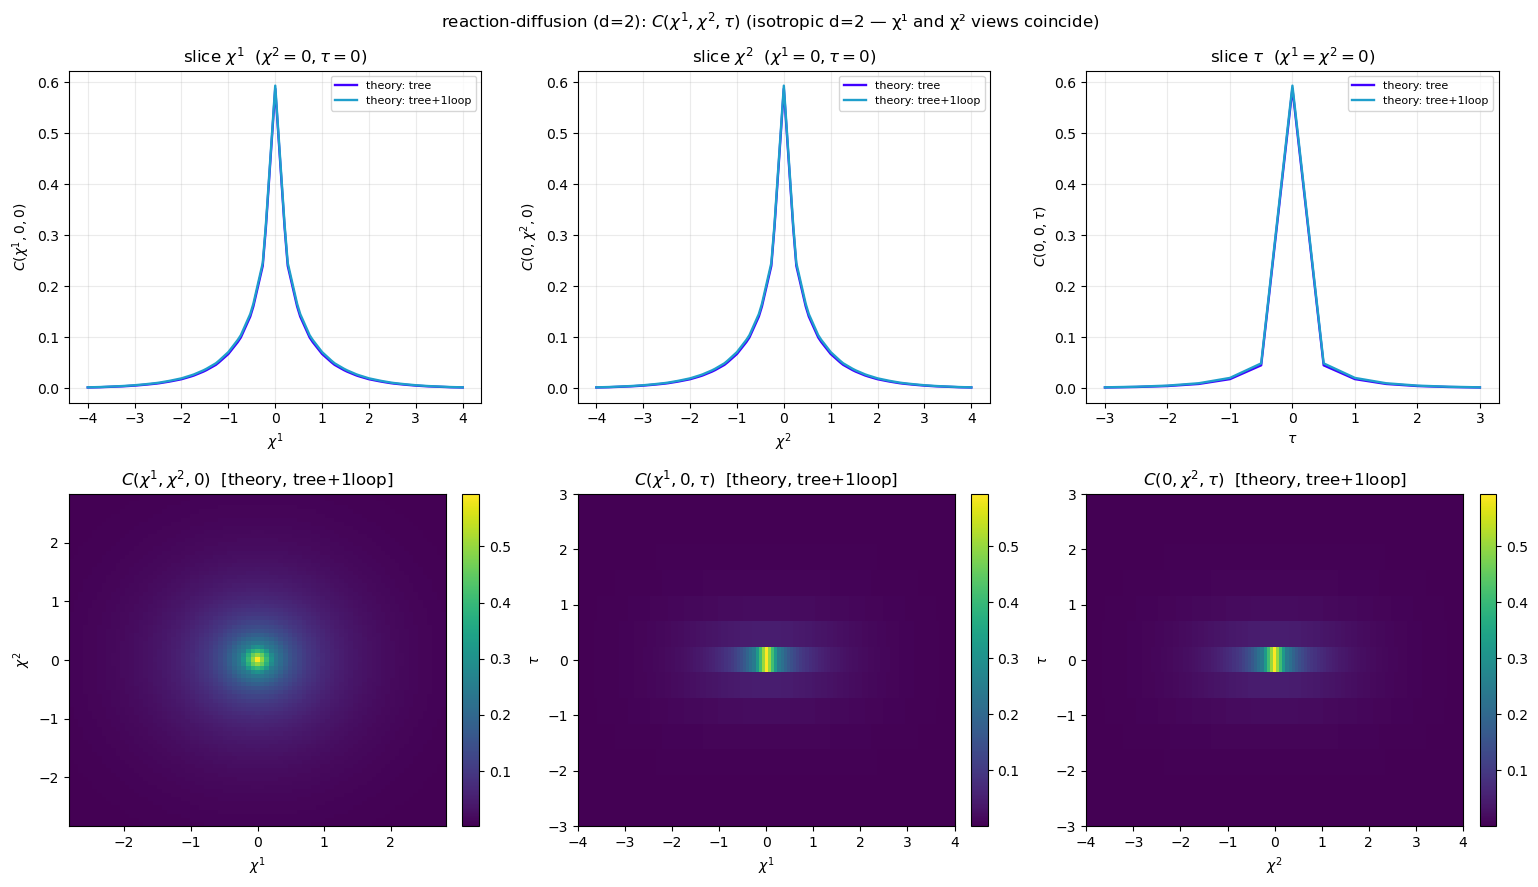

In [4]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
# the d=2 highlight: the 1-loop bubble is FINITE (no cutoff) because d=2 < 4.
by   = (res.get('spatial_info') or {}).get('C_by_order') or {}
mid  = int(np.argmin(np.abs(res['tau_grid'])))          # τ = 0 row
tree = np.real(by[0])[mid]; full = np.real(by[1])[mid]
dC   = full - tree                                       # the d=2 bubble correction
print('1-loop bubble finite? %s   max|ΔC(r)| = %.4g   (d=2 < 4 → no cutoff)'
      % (bool(np.all(np.isfinite(dC))), float(np.max(np.abs(dC)))))
dd.plot_cumulant(res, cfg, model)   # model only — tree and tree+1loop overlaid
plt.show()

## 3. Independent simulation — the full C(χ¹,χ²,τ)

A direct 2-D SPDE integration (no diagrammatics). We build the connected space-time correlator C(χ¹,χ²,τ) from the snapshots and overlay it on the model: **sim points on the three slices** and a **matching row of sim heatmaps** on the shared colour scale. The agreement is clean for the spatial structure (|χ| ≳ 1); near the origin the equal-point value is UV-regularized differently on the lattice than in the continuum model (the d=2 propagator is log-singular at r→0), so the on-site (r=0) point and the C(0,0,τ) slice differ slightly there.

equal-time C(χ¹=1, 0, 0):  model = 0.0712   sim = 0.0657   (bulk; the r=0 point is UV-sensitive)


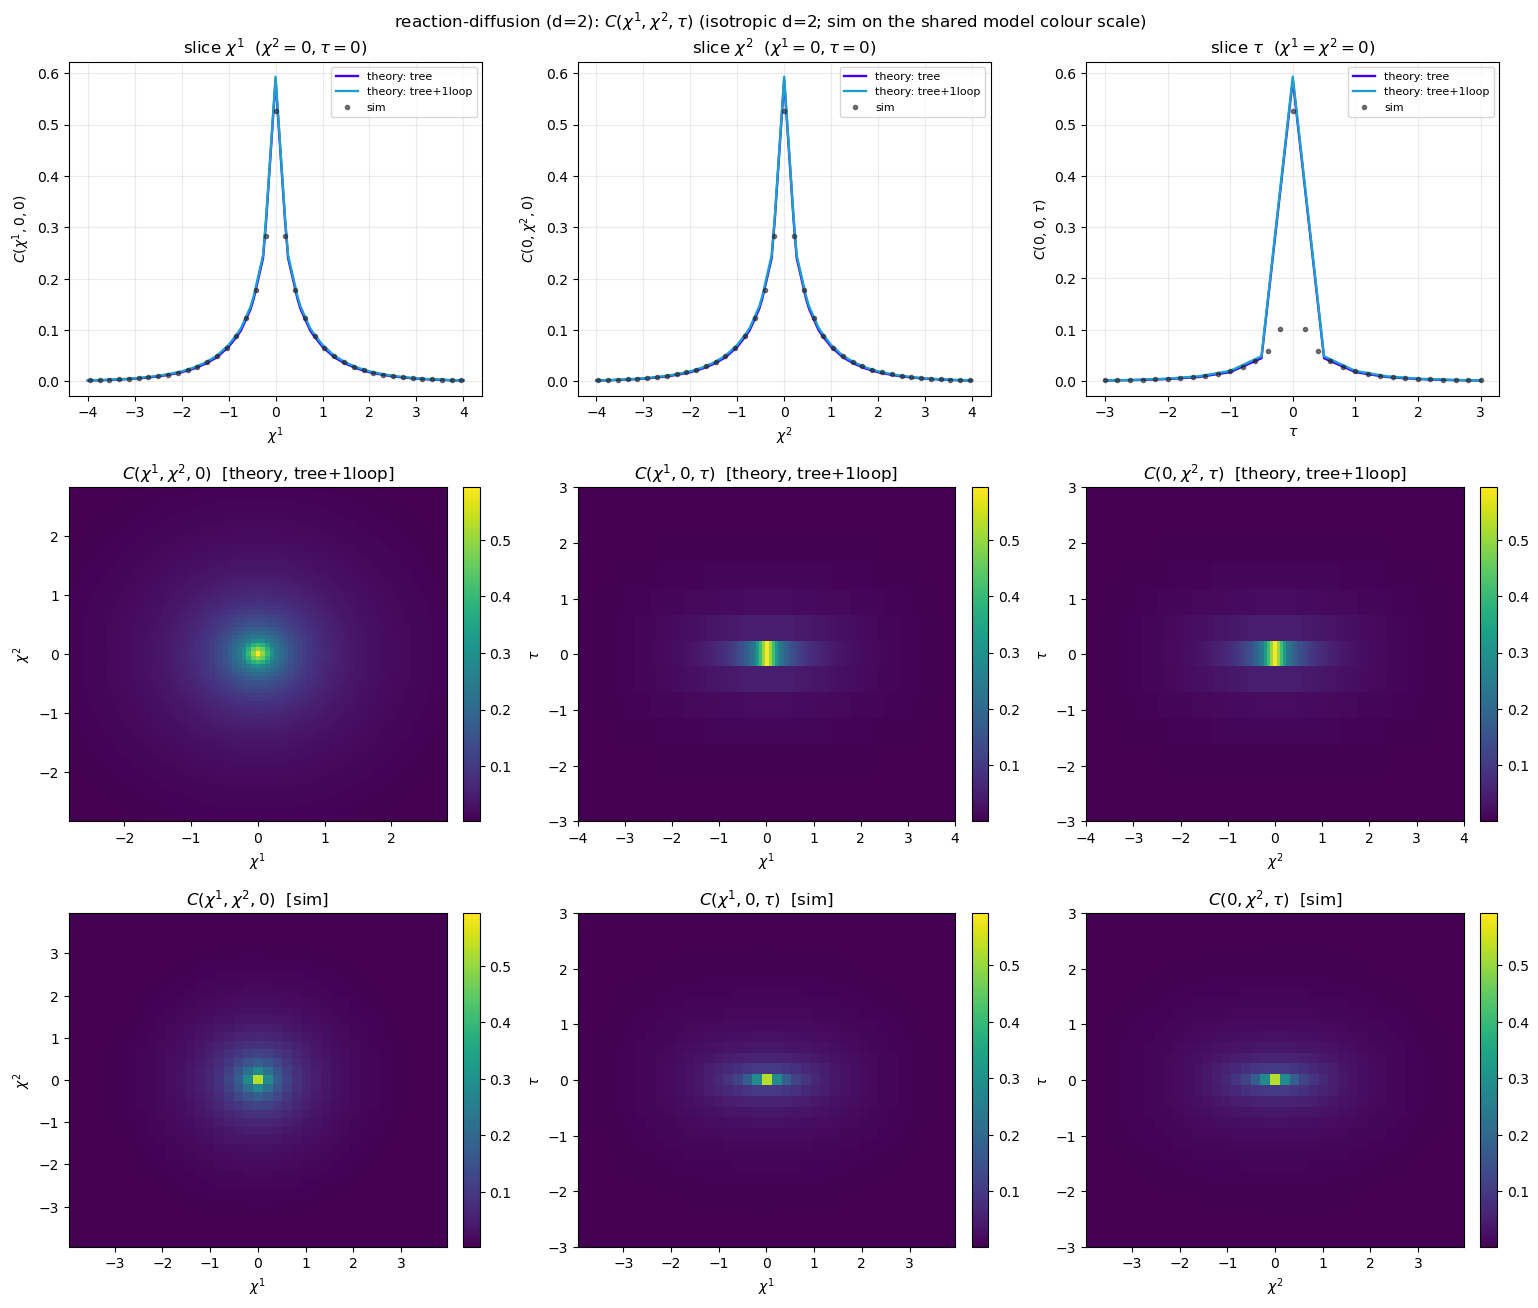

In [5]:
# Full 2-D space-time correlator C(χ¹,χ²,τ) from the field snapshots — CONNECTED
# (no diagrammatics).  C_s[i,a,b] = ⟨δφ(x) δφ(x+χ)⟩ at χ¹=chi_s[a], χ²=chi_s[b], τ=tau_s[i].
from simulations.spatial_field_2d_sim import simulate_2d, space_time_correlator_2d
fp = dd.parameters_from_model(model)
snaps, meta = simulate_2d(L=20.0, N=96, mu=fp['mu'], D=fp['D'], T=fp['T'], g=fp['g'],
                          n_steps=100000, burn_in=20000, record_every=10, seed=3)
tau_s, chi_s, C_s = space_time_correlator_2d(snaps, meta,
                        max_lag=float(np.max(np.abs(res['tau_grid']))))
sim = {'chi': chi_s, 'tau': tau_s, 'C': C_s}

# quantitative anchor at a bulk point (away from the UV-sensitive r=0)
midt = res['C_tau_x'].shape[0] // 2
ic   = int(np.argmin(np.abs(chi_s))); i1 = ic + int(round(1.0 / (chi_s[1] - chi_s[0])))
print('equal-time C(χ¹=1, 0, 0):  model = %.4f   sim = %.4f   (bulk; the r=0 point is UV-sensitive)'
      % (float(np.interp(1.0, res['spatial_grid'], np.real(res['C_tau_x'])[midt])),
         float(C_s[int(np.argmin(np.abs(tau_s)))][i1][ic])))
# overlay: sim points on the 3 slices + a matching row of sim heatmaps (shared colour scale)
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## 4. Fourier cross-checks

Two checks that sidestep the real-space r=0 UV: the free (g=0) structure factor S(q) against the tree propagator, and the g²-scaling of the loop (a genuine O(g²) bubble; tree is g-independent at φ*=0).

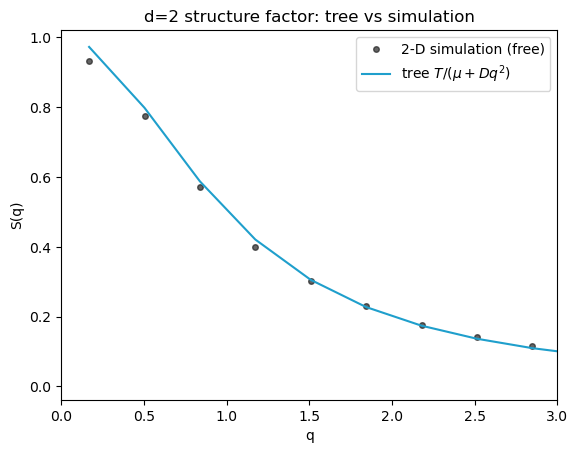

ΔC(2g) / ΔC(g) at r0 = 4.00   (an O(g²) bubble → 4.0)


In [6]:
# Independent 2-D simulation (direct ETD1 on an N×N grid) — NOT the pipeline.
# In d=2 the real-space C(r) tail is finite-size-limited, so the clean validations are
# (a) the free (g=0) STRUCTURE FACTOR S(q) against the tree propagator T/(μ+Dq²), and
# (b) the g²-scaling of the loop (a genuine O(g²) bubble; tree is g-independent at φ*=0).
from simulations.spatial_field_2d_sim import simulate_2d, radial_structure_factor_2d
fp = dd.parameters_from_model(model)
snaps, meta = simulate_2d(L=20.0, N=64, mu=fp['mu'], D=fp['D'], T=fp['T'], g=0.0,
                          n_steps=50000, burn_in=10000, record_every=15, seed=3)
kc, Sq = radial_structure_factor_2d(snaps, meta, n_bins=30)
plt.plot(kc, Sq, 'o', ms=4, color='#222', alpha=0.7, label='2-D simulation (free)')
plt.plot(kc, fp['T'] / (fp['mu'] + fp['D'] * kc**2), '-', color='#1F9FCC',
         label=r'tree $T/(\mu+Dq^2)$')
plt.xlim(0, 3); plt.xlabel('q'); plt.ylabel('S(q)'); plt.legend()
plt.title('d=2 structure factor: tree vs simulation'); plt.show()

# (b) g²-scaling of the loop: doubling g quadruples ΔC.
loop2 = dd.run(model, dd.Config(k=2, max_ell=1, external_fields=[('dphi', 1), ('dphi', 1)],
               parameters={**fp, 'g': 2 * fp['g']}, chi_grid=rs, tau_grid=[0.0]), mod)
dC2 = np.real((loop2.get('spatial_info') or {}).get('C_by_order')[1])[0] - tree
print('ΔC(2g) / ΔC(g) at r0 = %.2f   (an O(g²) bubble → 4.0)' % (dC2[0] / dC[0]))

## Summary

The d=2 reaction–diffusion bubble is the pipeline **above one dimension with a finite loop**: the cubic vertex's momentum-dependent self-energy converges (d=2 < 4, no cutoff). The simulation reproduces the full C(χ¹,χ²,τ) — slices and heatmaps — away from the UV-sensitive origin, the free structure factor matches in Fourier space, and the loop scales as g² as a genuine bubble must.